In [33]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import pandas as pd


sns.set_context("paper", font_scale=1.4)

data = pd.read_csv("training_history.csv")
data.head()

,epoch,train_loss,test_loss
0,1,0.378283,0.085141
1,2,0.300880,0.182069
2,3,0.239598,0.330664
3,4,0.262453,0.310894
4,5,0.254039,0.251036


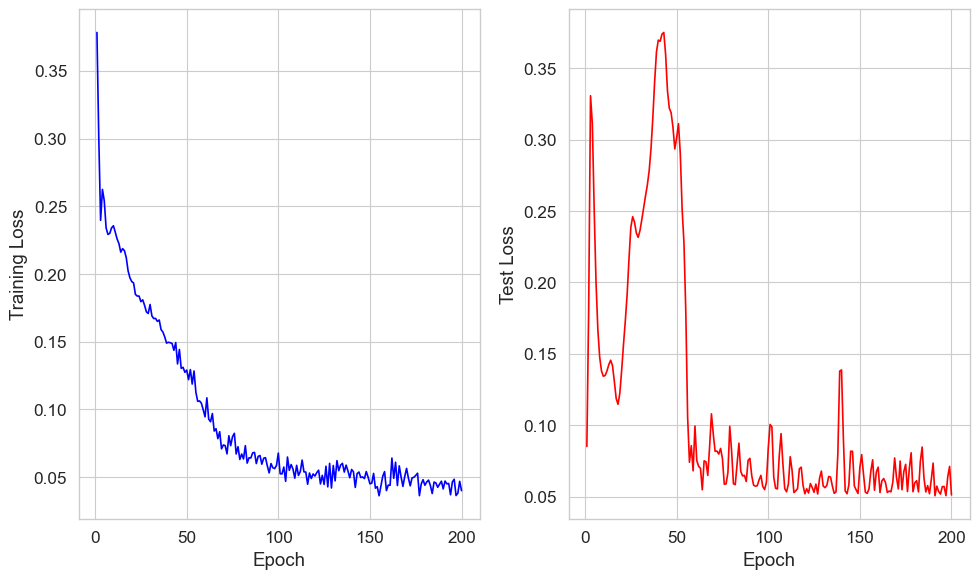

In [34]:
# Plotting the training and validation loss
fig, ax = plt.subplots(figsize=(10, 6), nrows = 1, ncols = 2)
sns.lineplot(data = data, x = "epoch", y = "train_loss", ax=ax[0], color="blue")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")
sns.lineplot(data, x="epoch", y="test_loss", ax=ax[1], color="red")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Test Loss")
plt.tight_layout()
plt.show()


In [40]:
# Predictions
trainingset = pd.read_csv("true_vs_pred_train.csv")
testset = pd.read_csv("true_vs_pred_test.csv")
trainingset.tail()

,sample_index,true_train,pred_train
48,48,1.677800,1.956701
49,49,1.887525,1.877252
50,50,2.621562,2.078898
51,51,2.202112,1.708289
52,52,1.141881,1.195931


In [42]:
testset["sample_index"] = testset["sample_index"] + 53
testset.head()

,sample_index,true_test,pred_test
0,53,1.245688,1.074860
1,54,1.245688,1.278409
2,55,0.830459,1.303666
3,56,1.245688,1.307951
4,57,1.349495,1.349689


Text(0, 0.5, 'VF Rate')

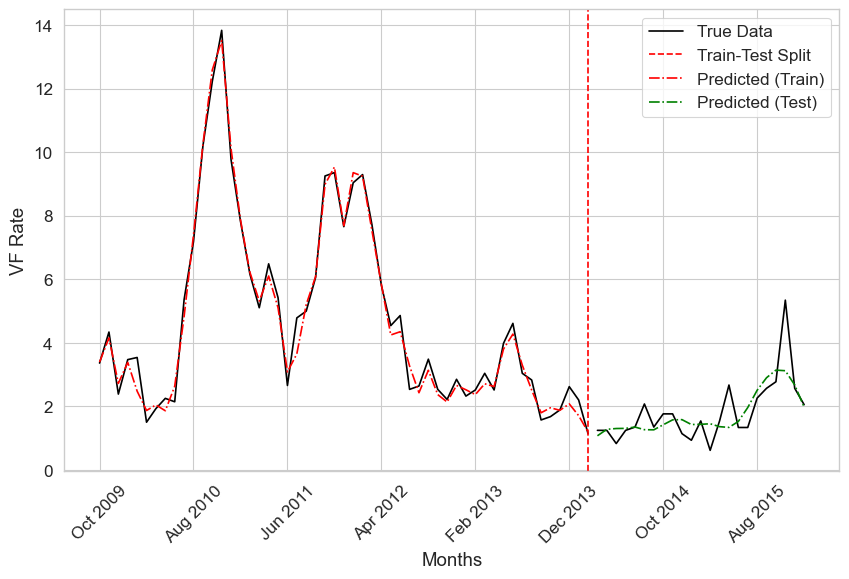

In [62]:
plt.figure(figsize=(10,6))
ax = sns.lineplot(data=trainingset, x="sample_index", y="true_train", color="black", label="True Data")
ax.axvline(x=52, color='red', linestyle='--', label="Train-Test Split")
sns.lineplot(data=testset, x="sample_index", y="true_test", color="black", label="_truedata")
sns.lineplot(data=trainingset, x="sample_index", y="pred_train", linestyle="-.", color='red', label="Predicted (Train)")
sns.lineplot(data=testset, x="sample_index", y="pred_test", linestyle="-.", color="green", label="Predicted (Test)")
plt.legend()
# 1. Create the date range to match your 75 samples
dates = pd.date_range(start='2009-10-01', periods=75, freq='MS')


# 2. Select every 10th index
tick_indices = list(range(0, 75, 10))

# 3. Format the labels (e.g., 'Oct 2009', 'Aug 2010', etc.)
tick_labels = [dates[i].strftime('%b %Y') for i in tick_indices]

# 4. Apply to your plot
plt.xticks(tick_indices, tick_labels, rotation=45)
ax.set_xlabel("Months")
ax.set_ylabel("VF Rate")